In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import sklearn as sk
import kagglehub
from sklearn.preprocessing import LabelEncoder,StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score,mean_squared_error, root_mean_squared_error, roc_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import lightgbm as lgb
from functions import hist_plot, bar_plot
from sklearn.linear_model import LogisticRegression
import kagglehub
from sklearn.cluster import KMeans


threshold = 0.5
random_state = 18


/Users/mariahwaslie/Desktop/ML_Data_exploration/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
# Download latest version
path = kagglehub.dataset_download("zusmani/mygenome")
print("Path to dataset files:", path)

Path to dataset files: /Users/mariahwaslie/.cache/kagglehub/datasets/zusmani/mygenome/versions/2


In [3]:
path = r'ML /k-means/Mother Genome.csv'
p = pd.read_csv(path)
df = pd.DataFrame(p)
print(df.info())
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'ML /k-means/Mother Genome.csv'

In [28]:
for col in df:
    print(df[col].unique())

['rs12564807' 'rs3131972' 'rs148828841' ... 'i4990307' 'i4000756'
 'i3001931']
[1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 '18' '19' '20' '21' '22' 'X'
 'Y' 'MT']
[734462 752721 760998 ...  16527  16540  16547]
['AA' 'GG' 'CC' 'AG' 'AC' 'CT' 'GT' 'CG' '--' 'TT' 'AT' 'II' 'DD' 'DI' 'T'
 'A' 'G' 'C' 'I']


In [29]:
def convert_value(val):
    try:
         return str(val)
    except ValueError:
         return val 
     
df['chromosome'] = df['chromosome'].apply(convert_value)
df['chromosome'].unique()


array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', 'X',
       'Y', 'MT'], dtype=object)

In [30]:
from sklearn.preprocessing import OneHotEncoder

encoder  = OneHotEncoder(sparse_output=False, drop=None)
catagorical_cols = ['chromosome','genotype']
# fit and transform the data 
encoded_array = encoder.fit_transform(df[catagorical_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns = encoder.get_feature_names_out(catagorical_cols)
)

# Drop original categorical columns and join the new one-hot columns
df = df.drop(columns=catagorical_cols).reset_index(drop=True)
df = pd.concat([df, encoded_df], axis=1)


In [31]:
drops = ['# rsid']
# df['position'].unique()
# one hot encode 
df = df.drop(drops, axis=1)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601802 entries, 0 to 601801
Data columns (total 45 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   position       601802 non-null  int64  
 1   chromosome_1   601802 non-null  float64
 2   chromosome_10  601802 non-null  float64
 3   chromosome_11  601802 non-null  float64
 4   chromosome_12  601802 non-null  float64
 5   chromosome_13  601802 non-null  float64
 6   chromosome_14  601802 non-null  float64
 7   chromosome_15  601802 non-null  float64
 8   chromosome_16  601802 non-null  float64
 9   chromosome_17  601802 non-null  float64
 10  chromosome_18  601802 non-null  float64
 11  chromosome_19  601802 non-null  float64
 12  chromosome_2   601802 non-null  float64
 13  chromosome_20  601802 non-null  float64
 14  chromosome_21  601802 non-null  float64
 15  chromosome_22  601802 non-null  float64
 16  chromosome_3   601802 non-null  float64
 17  chromosome_4   601802 non-nul

In [32]:
scaler = StandardScaler()

position_scaled = scaler.fit_transform(df[['position']])
df['position'] = position_scaled

X = df


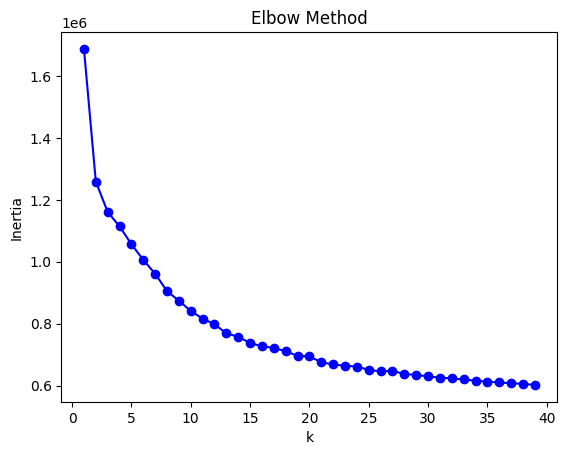

In [33]:

inertia = []
cluster_range = range(1, 40)
for cluster_num in cluster_range:
    kmeans = KMeans(n_clusters=cluster_num, random_state=random_state)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(cluster_range, inertia, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

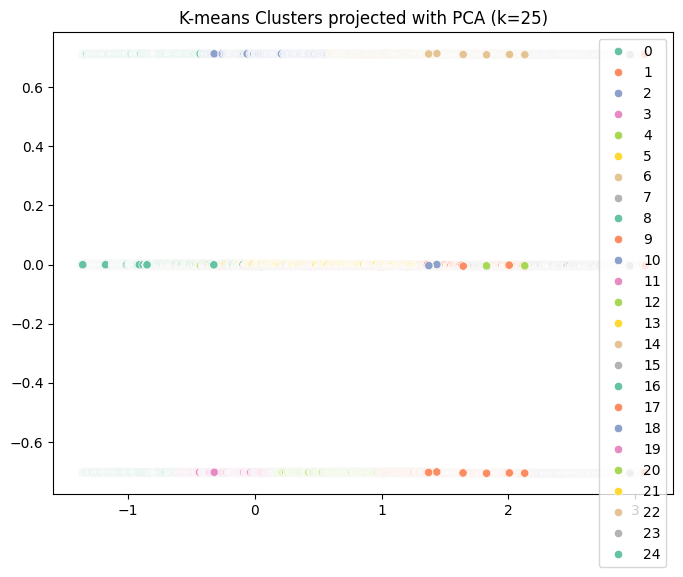

In [35]:
k= 25
kmeans = KMeans(n_clusters=k, random_state=random_state)
labels = kmeans.fit_predict(X)

from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette="Set2")
plt.title(f"K-means Clusters projected with PCA (k={k})")
plt.show()